# AG-HYPOPT · Trial 11

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

[Ten trials recorded; best is trial 09 (0.0182). Sequence: 01 0.0981, 02 0.0246, 03 0.0477, 04 0.0262, 05 0.0196, 06 0.0329, 07 0.0205, 08 0.0294, 09 0.0182, 10 0.0301. Trials 05/07/08/09/10 are all the same plateau point (lr_mu ~27, sigma_ref ~6.2, lr_gamma ~0.42, gamma_anneal ~0.39-0.42); their objectives span 0.0182-0.0301 and trial 08 vs trial 10 demonstrates that near-identical configs swing by ~65% purely through the low-count Trans05 runs. mu is stuck at 14.4-17.2% and no hyperparameter value has beaten trial 09's 14.4%; gamma swings 12.5-18.5%. The search has converged on the plateau; lr_mu peaks near 27, sigma_ref is monotone (smaller better, saturated below ~6.3). We are in the TPE phase (11th trial).]


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_11'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (10/5 trials)
ID |     ei | params
 1 | 1.6262 | {"gamma_anneal": 0.3744583968300862, "lr_gamma": 0.4185046731868624, "lr_mu": 28.20527557400924, "sigma_ref": 7.59547898798596}
 2 | 3.9997 | {"gamma_anneal": 0.39178946018911087, "lr_gamma": 0.41887397053258124, "lr_mu": 27.05500611275877, "sigma_ref": 20.760791890079837}
 3 | 3.9996 | {"gamma_anneal": 0.4139663613017954, "lr_gamma": 0.4177827906922226, "lr_mu": 26.939115460966764, "sigma_ref": 6.136836327252753}
 4 | 3.9892 | {"gamma_anneal": 0.3791344604310565, "lr_gamma": 0.8417621470227867, "lr_mu": 26.992541345885265, "sigma_ref": 6.16084620609967}
 5 | 3.9993 | {"gamma_anneal": 0.6719582311877756, "lr_gamma": 0.4186923190869375, "lr_mu": 27.02720182140999, "sigma_ref": 6.238931230288509}
 6 | 3.9977 | {"gamma_anneal": 0.1505767156209145, "lr_gamma": 0.4178137948283916, "lr_mu": 26.962408156233174, "sigma_ref": 6.180582112128475}
 7 | 3.9696 | {"gamma_anneal": 0.7473269066547529, "lr_gamma": 0.41969341284007267, "lr

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

[Best is trial 09 (0.0182); trials 05/07/08/09/10 are the same plateau config, with trial 10 showing a 65% objective swing versus trial 09 at nearly identical settings. The TPE batch again concentrates on the plateau: #2 (ei 3.9997) actually has the top ei but sigma_ref 20.8, far outside the good region (sigma_ref is monotone in mu error, so that draw is ruled out); the best draw inside the good region is #3 (ei 3.9996: lr_mu 26.94, sigma_ref 6.137, lr_gamma 0.418, gamma_anneal 0.414), essentially the trial 09 point. Since the campaign has demonstrably converged and the objective is noise-limited, the sensible move is to take the highest-ei good-region draw, candidate 3, to add another sample of the floor (the model needs repeated measurements because single-run differences exceed the tunable effects). Candidate 4 (lr_gamma 0.84) and candidate 5 (gamma_anneal 0.67) would probe the gamma direction, but neither has helped before. I choose candidate 3.]


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 3               # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.4139663613017954, 'lr_gamma': 0.4177827906922226, 'lr_mu': 26.939115460966764, 'sigma_ref': 6.136836327252753}
Running  1nW Trans05 ... 

μ 9.39 -> 6.89 | γ 8.5 -> 9.32 | NLL 1.30


Running  1nW Trans20 ... 

μ 17.32 -> 15.81 | γ 8.5 -> 7.90 | NLL 2.80


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 100.17 | γ 14.1 -> 13.73 | NLL 3.35


Running 3nW Trans100 ... 

μ 175.71 -> 161.07 | γ 14.1 -> 13.86 | NLL 2.94



Total: 7.1 min


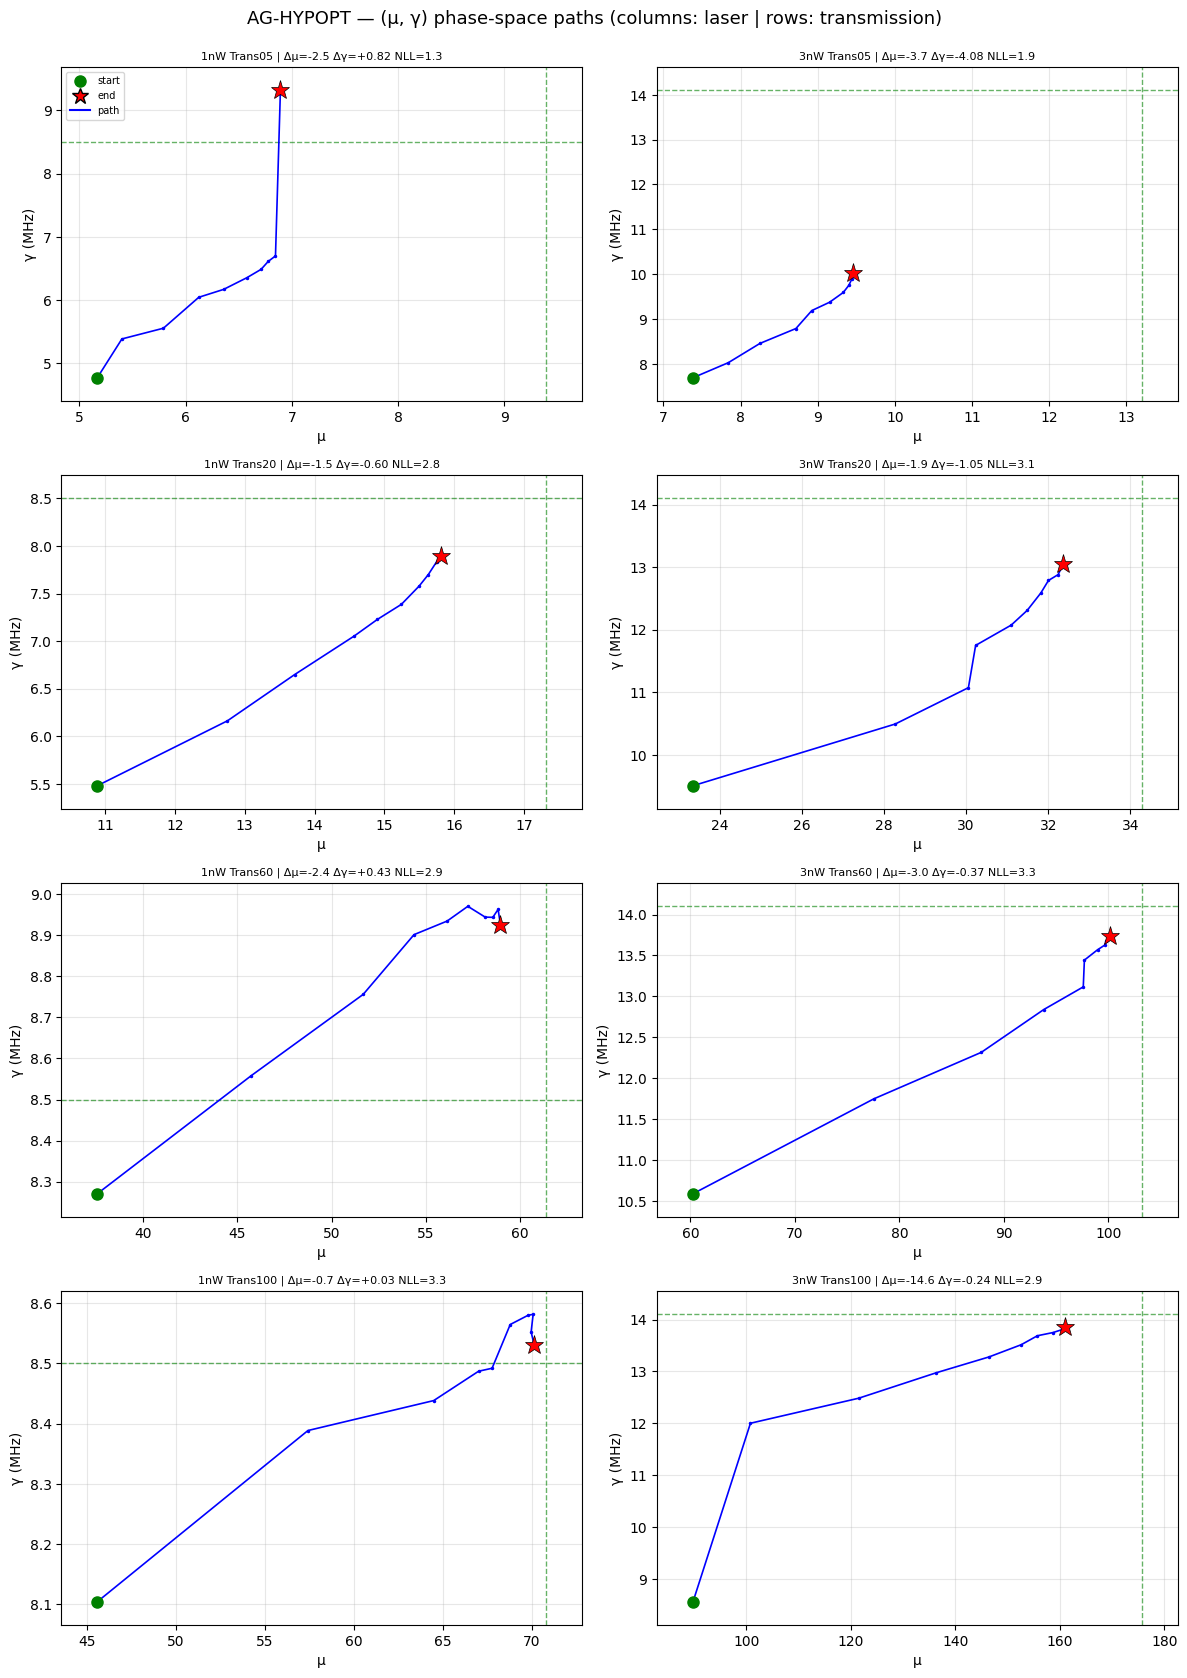

trial finished in 7.1 min
objective = 0.0174 ± 0.0076
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    6.89   -26.6 |     8.50    9.32    +9.6
1nW Trans20    17.32   15.81    -8.7 |     8.50    7.90    -7.1
1nW Trans60    61.37   58.95    -3.9 |     8.50    8.93    +5.0
1nW Trans100   70.82   70.15    -0.9 |     8.50    8.53    +0.4
3nW Trans05    13.20    9.46   -28.3 |    14.10   10.02   -28.9
3nW Trans20    34.28   32.37    -5.6 |    14.10   13.05    -7.4
3nW Trans60   103.20  100.17    -2.9 |    14.10   13.73    -2.6
3nW Trans100  175.71  161.07    -8.3 |    14.10   13.86    -1.7

μ: RMSE 5.656 (rel 14.6%, bias -3.803) | γ: RMSE 1.547 (rel 11.6%, bias -0.633)


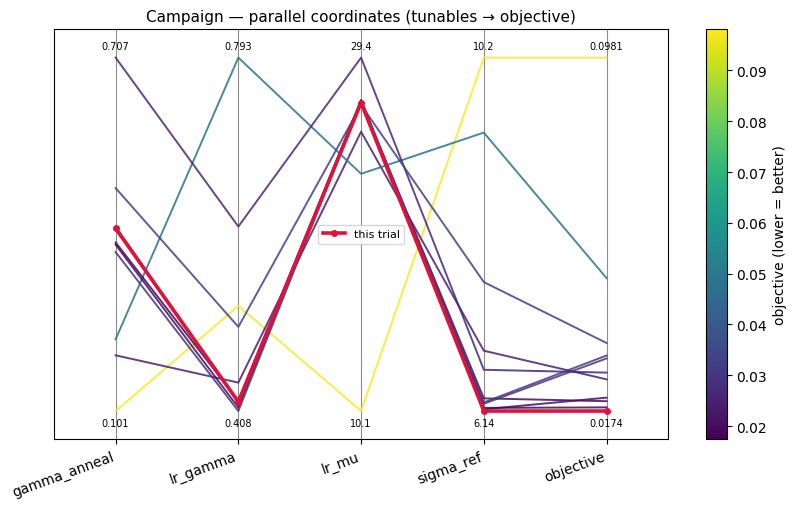

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 11 (sigma_ref 6.137, lr_mu 26.94, lr_gamma 0.418, gamma_anneal 0.414) is again the plateau point (the best good-region draw; the batch's nominal top-ei #2 was excluded for sigma_ref 20.8). It ran 7.1 min and scored 0.0174 +/- 0.0076, the new best, with mu 14.6% and gamma 11.6% (best gamma so far). Like trials 05/07/09 it is the same (lr_mu ~27, sigma_ref ~6.2) configuration; the objective now spans 0.0174-0.0301 across these runs of one point, entirely through the Trans05 gamma noise (this time 1nW Trans05 gamma was +9.6% and 3nW Trans05 -28.9%, both relatively benign). Trials 09 (0.0182) and 11 (0.0174) are statistically indistinguishable, so the plateau is the optimum and the search has converged; further gains would need a change outside these four tunables.

**Summary:** Trial 11 (sigma_ref 6.137, lr_mu 26.94, lr_gamma 0.418, gamma_anneal 0.414), the plateau point again, scored 0.0174 +/- 0.0076, the new best (mu 14.6%, gamma 11.6%), confirming the optimum and the ~0.017-0.030 noise band.
**Key insight:** Four runs of the plateau config span 0.0174-0.0301 purely from Trans05 gamma noise; trial 11 (0.0174) is the best so far, and no tunable change has beaten this point.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none this trial.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 11 (sigma_ref 6.137, lr_mu 26.94, lr_gamma 0.418, gamma_anneal 0.414), the plateau point again, scored 0.0174 +/- 0.0076, the new best (mu 14.6%, gamma 11.6%), confirming the optimum and the ~0.017-0.030 noise band.'
KEY_INSIGHT = 'Four runs of the plateau config span 0.0174-0.0301 purely from Trans05 gamma noise; trial 11 (0.0174) is the best so far, and no tunable change has beaten this point.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_11 | current best: trial_11


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_12.ipynb. Open it and follow its cells from the top.
